In [38]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [39]:
true_classes = np.load("../model/true_classes.npy")

predicted_classes = np.load("../model/predicted_classes.npy")

class_names = np.load("../model/class_names.npy")

In [40]:
print(np.unique(true_classes))

[4 5]


In [41]:
model = load_model("../model/waste_classifier.keras")

In [42]:
report = classification_report(
    true_classes,
    predicted_classes,
    target_names=class_names,
    zero_division=0
)

print(report)

              precision    recall  f1-score   support

   cardboard       0.00      0.00      0.00         0
       glass       0.00      0.00      0.00         0
       metal       0.00      0.00      0.00         0
       paper       0.00      0.00      0.00         0
     plastic       0.97      0.91      0.94       368
       trash       1.00      0.77      0.87       137

    accuracy                           0.87       505
   macro avg       0.33      0.28      0.30       505
weighted avg       0.97      0.87      0.92       505



In [ ]:
predictions = model.predict(val_dataset)

16/16 ━━━━━━━━━━━━━━━━━━━━ 10s 521ms/step


In [22]:
predicted_classes = np.argmax(predictions, axis=1)

In [31]:
true_classes = []

for images, labels in val_dataset:
    
    true_classes.extend(labels.numpy())

true_classes = np.array(true_classes)

In [32]:
print(np.unique(true_classes))

[4 5]


In [24]:
report = classification_report(
    true_classes,
    predicted_classes,
    labels=[0,1,2,3,4,5],
    target_names=class_names,
    zero_division=0
)

print(report)

              precision    recall  f1-score   support

   cardboard       0.00      0.00      0.00         0
       glass       0.00      0.00      0.00         0
       metal       0.00      0.00      0.00         0
       paper       0.00      0.00      0.00         0
     plastic       0.98      0.93      0.96       368
       trash       0.97      0.87      0.92       137

    accuracy                           0.91       505
   macro avg       0.32      0.30      0.31       505
weighted avg       0.98      0.91      0.94       505



In [25]:
cm = confusion_matrix(
    true_classes,
    predicted_classes
)

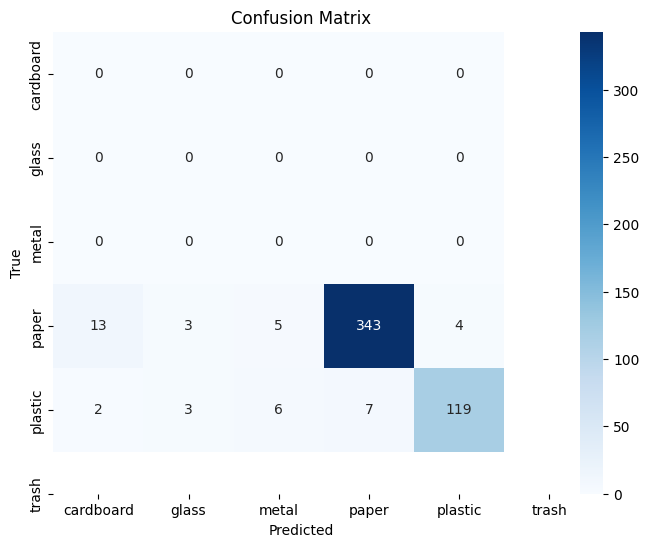

In [26]:
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("True")

plt.title("Confusion Matrix")

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


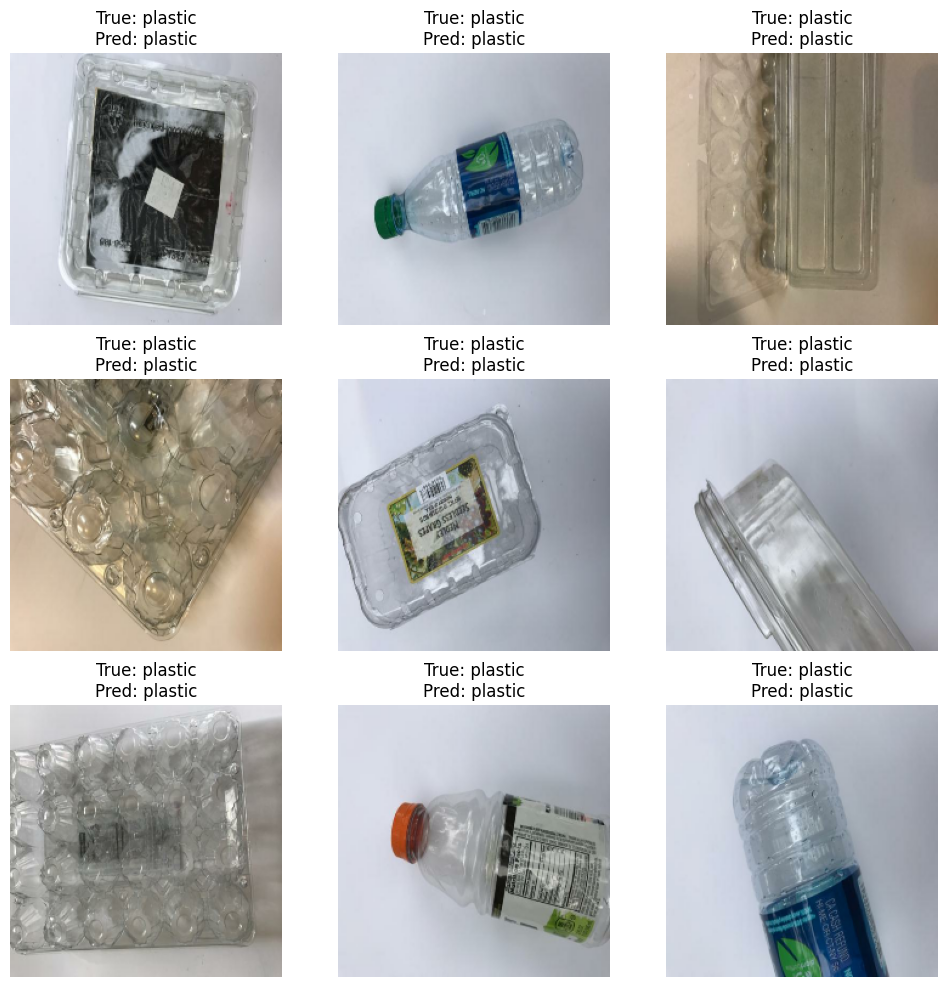

In [27]:
plt.figure(figsize=(12,12))

for images, labels in val_dataset.take(1):

    predictions = model.predict(images)

    predicted_labels = np.argmax(predictions, axis=1)

    for i in range(9):

        ax = plt.subplot(3,3,i+1)

        plt.imshow(images[i].numpy().astype("uint8"))

        true_label = class_names[labels[i]]
        predicted_label = class_names[predicted_labels[i]]

        plt.title(f"True: {true_label}\nPred: {predicted_label}")

        plt.axis("off")

Text(0.5, 1.0, 'True: plastic\nPred: plastic\n87.6%')

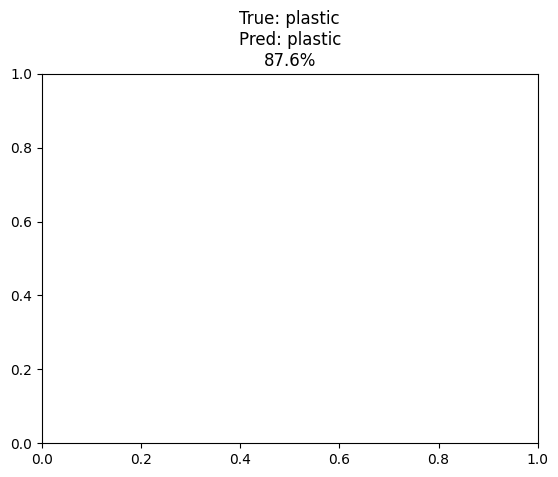

In [28]:
confidence = np.max(predictions[i]) * 100

plt.title(
    f"True: {true_label}\nPred: {predicted_label}\n{confidence:.1f}%"
)

In [29]:
import os

print(os.listdir("../dataset"))

['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [30]:
print(val_dataset.class_names)

['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
